rep 1/200
rep 5/200
rep 10/200
rep 15/200
rep 20/200
rep 25/200
rep 30/200
rep 35/200
rep 40/200
rep 45/200
rep 50/200
rep 55/200
rep 60/200
rep 65/200
rep 70/200
rep 75/200
rep 80/200
rep 85/200
rep 90/200
rep 95/200
rep 100/200
rep 105/200
rep 110/200
rep 115/200
rep 120/200
rep 125/200
rep 130/200
rep 135/200
rep 140/200
rep 145/200
rep 150/200
rep 155/200
rep 160/200
rep 165/200
rep 170/200
rep 175/200
rep 180/200
rep 185/200
rep 190/200
rep 195/200
rep 200/200
STD_ZIB common-baseline check: max RMSE difference = 0.000e+00

Saved:
zib_partial_revelation_cf_runs/detail_results.csv
zib_partial_revelation_cf_runs/summary_results.csv

Summary:


,scenario,rho,method,rmse_mean,rmse_sd,bias_mean,bias_sd,cover_mean,cover_sd,min_eig_mean,min_eig_sd,swap_var,alpha1_mean,beta1_mean
0,clean,0.00,PR_MLE,0.8676,0.6113,0.7372,0.5337,0.5888,0.3810,0.8327,0.4160,0.5324,0.9046,0.7365
1,clean,0.00,STD_ZIB,0.8676,0.6113,0.7372,0.5337,0.5888,0.3810,0.8327,0.4160,0.5324,0.9046,0.7365
2,clean,0.01,DR_CF,0.9683,0.0995,0.9171,0.0767,0.0006,0.0088,126.3793,11.9625,0.0352,0.2855,1.0896
3,clean,0.01,PR_MLE,0.2221,0.1121,0.1787,0.0862,0.9644,0.0806,2.5744,0.8233,0.0626,1.2036,0.4823
4,clean,0.01,STD_ZIB,0.8676,0.6113,0.7372,0.5337,0.5888,0.3810,0.8327,0.4160,0.5324,0.9046,0.7365
5,clean,0.02,DR_CF,0.9275,0.1309,0.8761,0.1215,0.0025,0.0216,127.2738,11.2663,0.0235,0.3284,1.0506
6,clean,0.02,PR_MLE,0.1757,0.0829,0.1427,0.0651,0.9619,0.0795,4.2703,0.8918,0.0356,1.2044,0.4949
7,clean,0.02,STD_ZIB,0.8676,0.6113,0.7372,0.5337,0.5888,0.3810,0.8327,0.4160,0.5324,0.9046,0.7365
8,clean,0.05,DR_CF,0.3234,0.1244,0.2836,0.1169,0.2025,0.1801,90.2618,19.0931,0.0595,0.9395,0.6289
9,clean,0.05,PR_MLE,0.1443,0.0678,0.1177,0.0530,0.9575,0.0881,8.2578,1.3493,0.0256,1.2069,0.4918


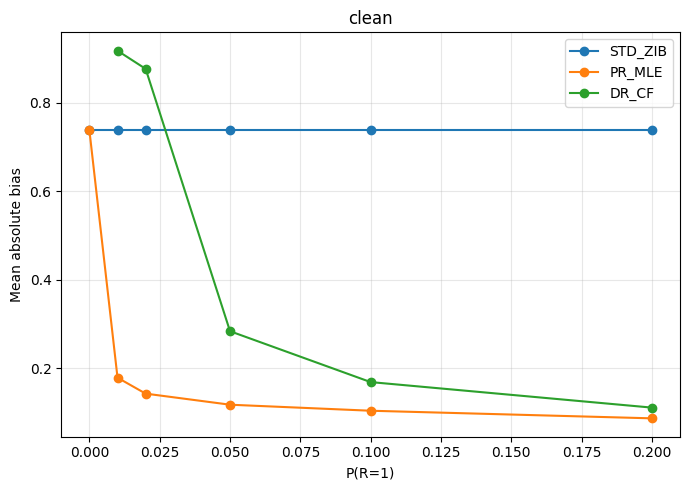

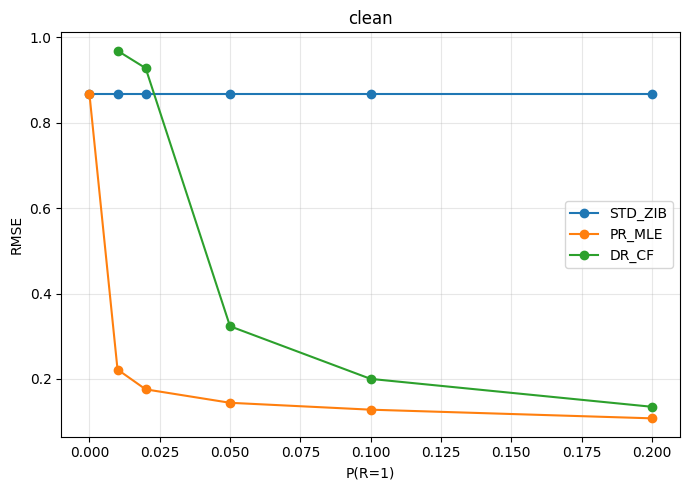

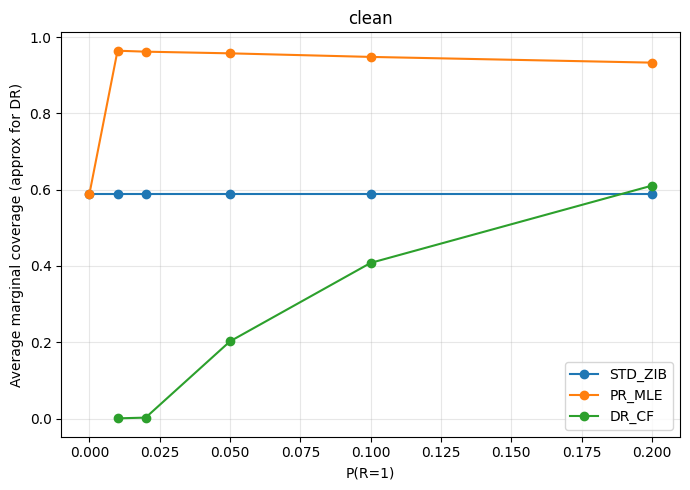

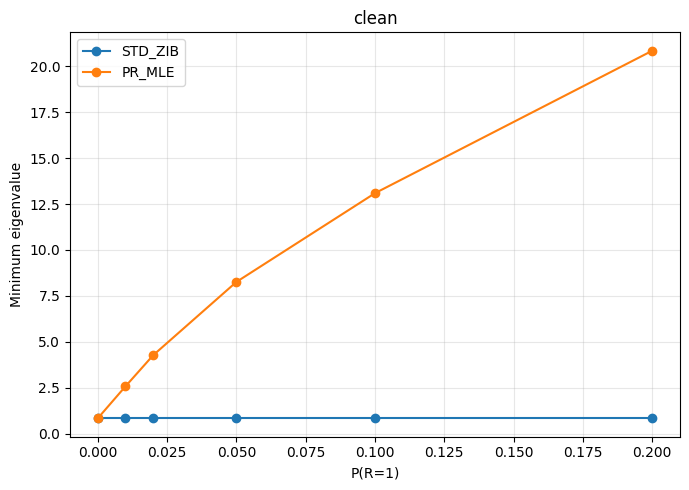

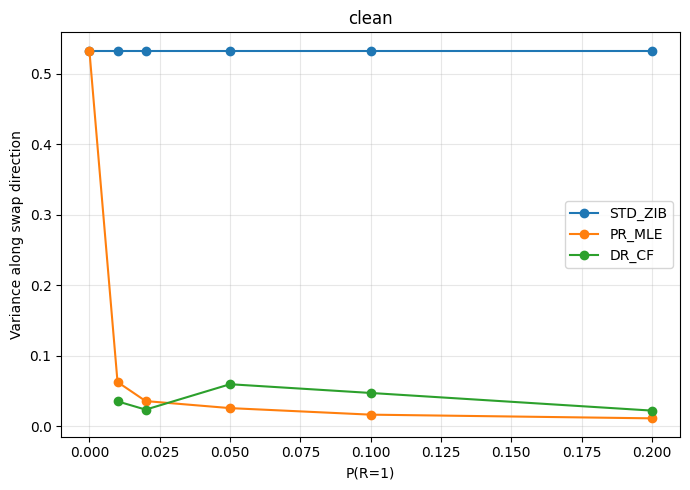

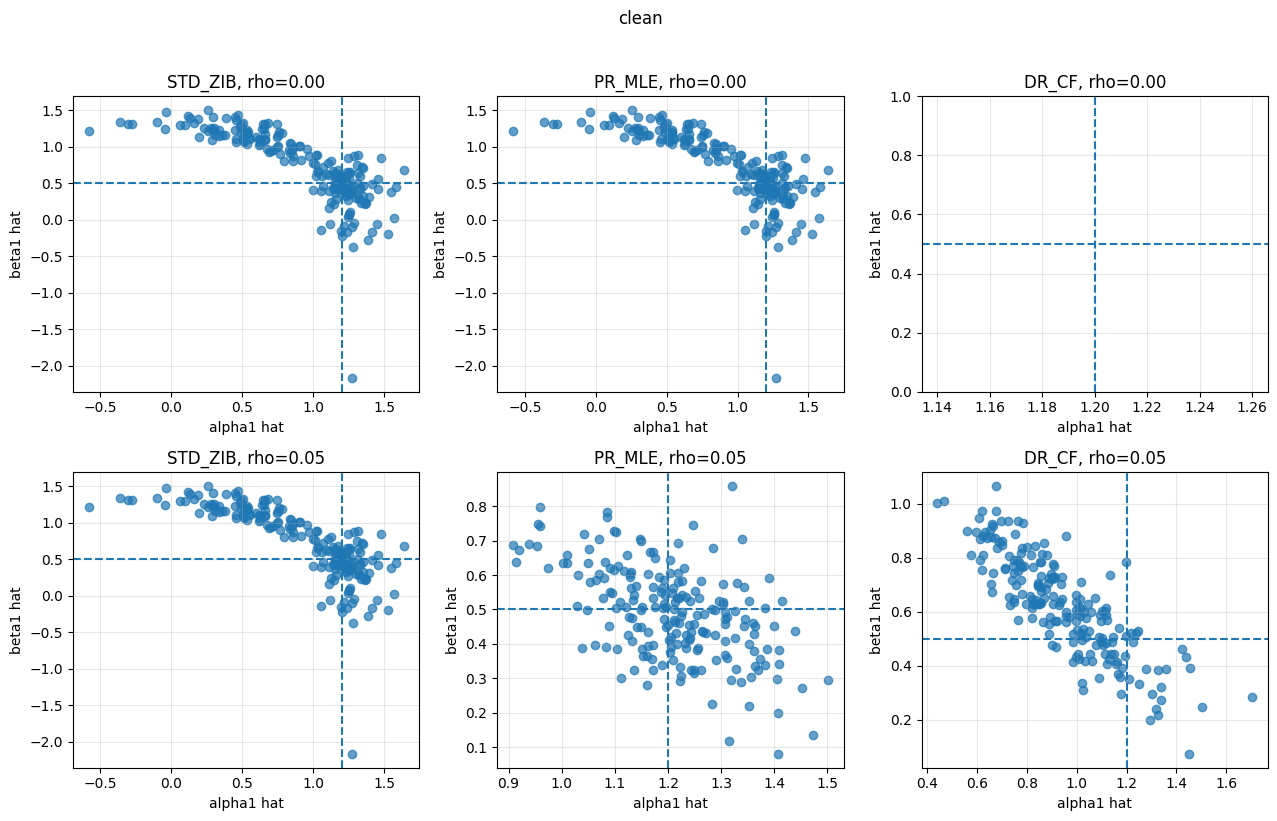

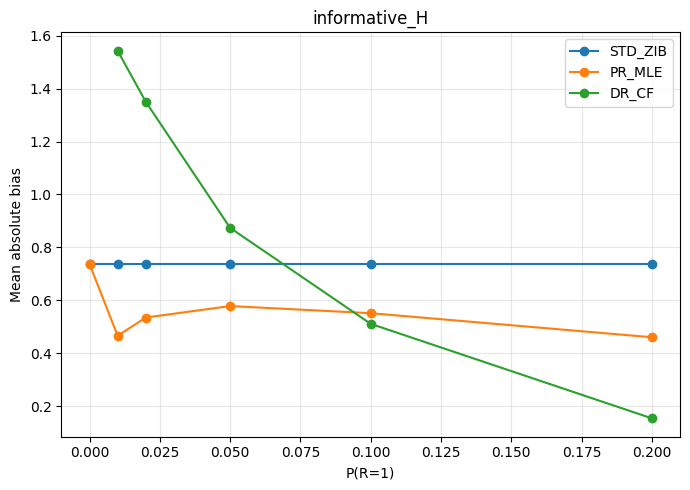

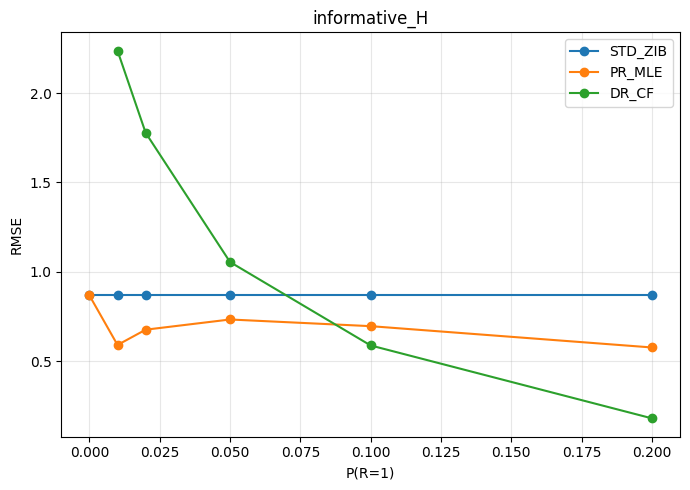

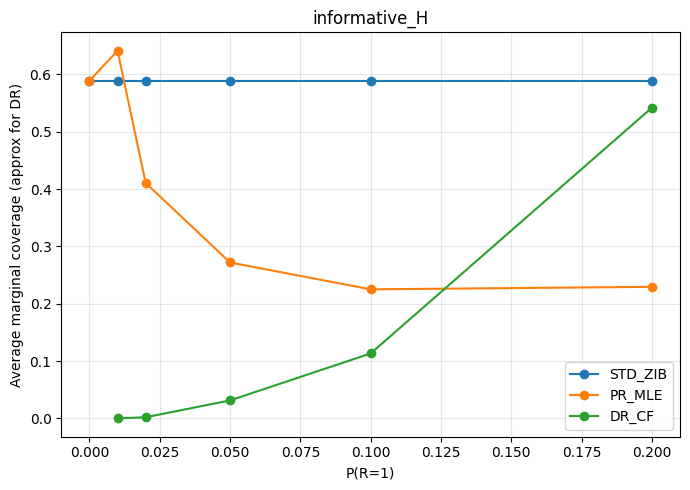

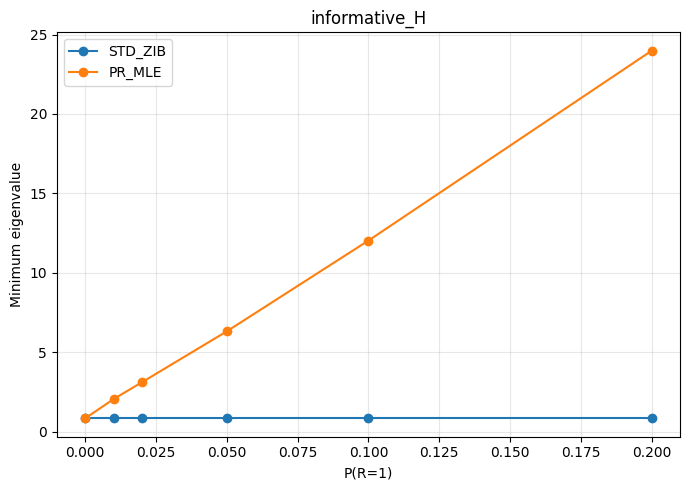

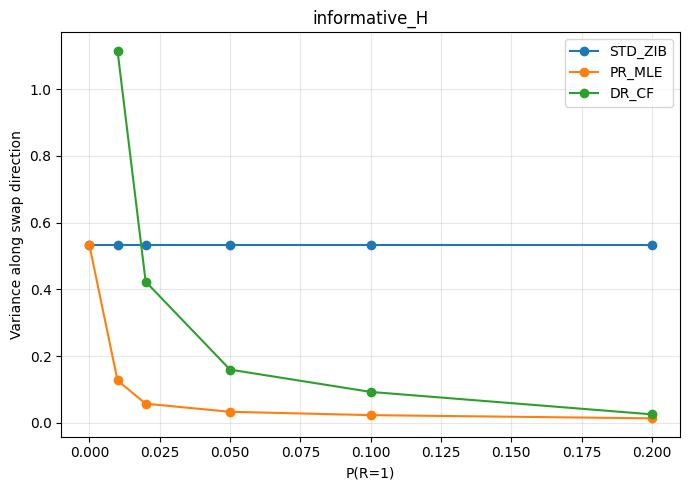

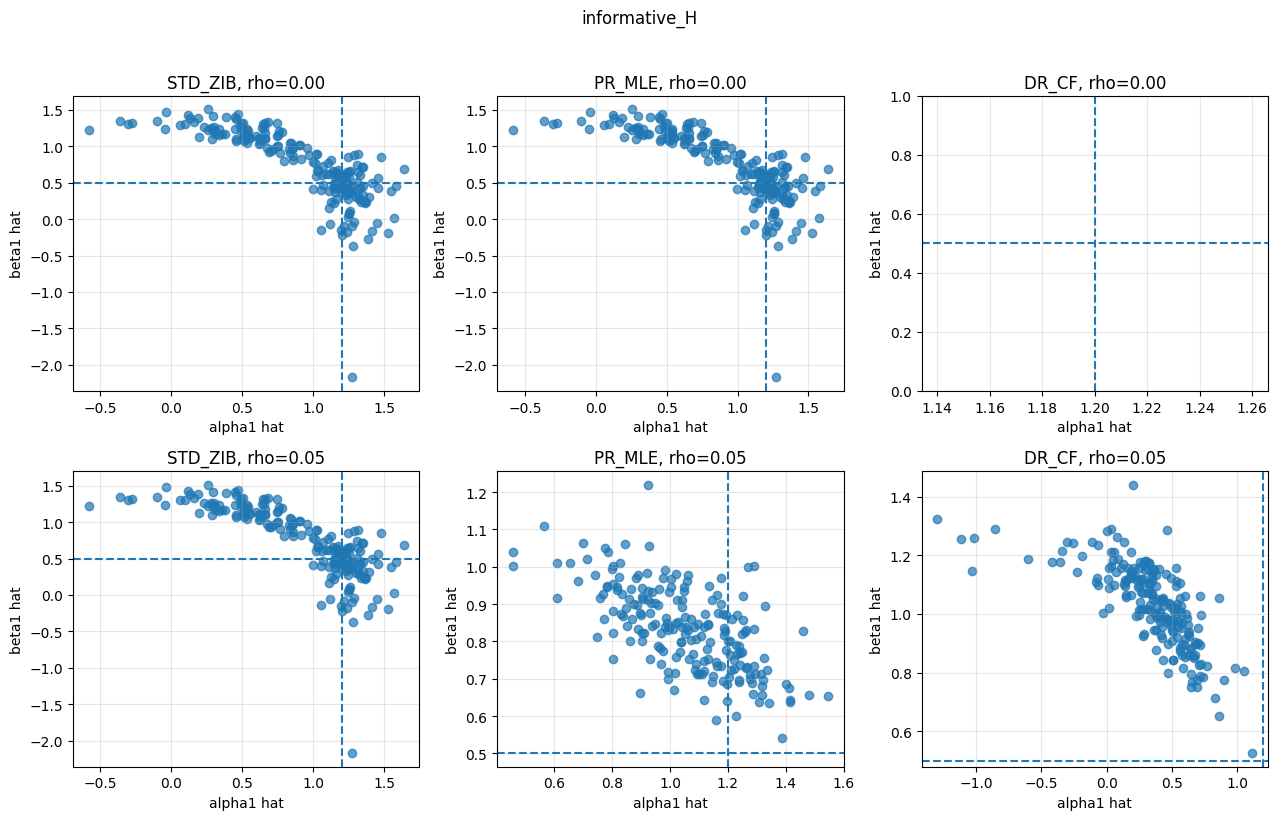


Done.


In [1]:
# ============================================================
# ZIB + partial revelation:
#   STD_ZIB vs PR_MLE vs DR_CF
#   with cross-fitting and misspecified informative-H scenario
# One-cell Colab code
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import expit
from scipy.optimize import brentq, minimize
from sklearn.model_selection import KFold
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# ------------------------------------------------------------
# configuration
# ------------------------------------------------------------
OUTDIR = "zib_partial_revelation_cf_runs"
os.makedirs(OUTDIR, exist_ok=True)

# quick check:
# N=2500, MC_REPS=30
# paper-quality:
# N=4000, MC_REPS=100
N = 2500
MC_REPS = 200
RHO_GRID = [0.00, 0.01, 0.02, 0.05, 0.10, 0.20]

# structural truth for S|X and Y|S,X
# X = (1, x1, x2, x3)
ALPHA_TRUE = np.array([-0.8,  1.2, -0.9,  0.6], dtype=float)
BETA_TRUE  = np.array([ 0.2,  0.5,  1.0, -0.6], dtype=float)

BASE_SEED = 2026

# cross-fitting
N_SPLITS = 5

# DR proxy stabilization
CLIP_SE = True
SE_CLIP_LO = 1e-4
SE_CLIP_HI = 1 - 1e-4

# approximate interval for DR is sandwich-based
# for publication-level interval calibration, bootstrap is safer

SCENARIOS = ["clean", "informative_H"]

# optimizer guard against non-identified ridge runaway
# This is not a statistical constraint; it prevents failed BFGS starts
# from dominating Monte Carlo averages.
MAX_ABS_THETA = 30.0

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def add_intercept(X):
    return np.column_stack([np.ones(len(X)), X])

def pinv_psd(H, ridge=1e-8):
    Hs = 0.5 * (H + H.T)
    vals, vecs = np.linalg.eigh(Hs)
    vals2 = np.where(vals > ridge, vals, ridge)
    return (vecs / vals2) @ vecs.T

def numerical_hessian_from_grad(grad_fun, theta, eps=1e-4):
    d = len(theta)
    H = np.zeros((d, d))
    for j in range(d):
        e = np.zeros(d)
        e[j] = eps
        gp = grad_fun(theta + e)
        gm = grad_fun(theta - e)
        H[:, j] = (gp - gm) / (2 * eps)
    return 0.5 * (H + H.T)

def fit_bfgs(loss_grad_fun, theta0, maxiter=400):
    return minimize(
        fun=lambda th: loss_grad_fun(th)[0],
        x0=theta0,
        jac=lambda th: loss_grad_fun(th)[1],
        method="BFGS",
        options={"gtol": 1e-6, "maxiter": maxiter, "disp": False},
    )

def multi_start_fit(fun, starts, max_abs_theta=MAX_ABS_THETA, require_success=False):
    """
    Multi-start optimizer with a guard against non-identified-ridge runaway.

    The standard ZIB likelihood identifies only q(x)=pi(x)mu(x), not the
    decomposition into pi and mu.  Along nearly flat directions, BFGS can
    sometimes return an enormous parameter vector with a finite objective and
    success=False.  Such a run should not be allowed to dominate RMSE averages.
    """
    best = None
    best_any = None

    for th0 in starts:
        try:
            res = fit_bfgs(fun, th0)

            finite = np.isfinite(res.fun) and np.all(np.isfinite(res.x))
            bounded = finite and (np.max(np.abs(res.x)) <= max_abs_theta)
            successful = (bool(res.success) or not require_success)

            if finite:
                if best_any is None or res.fun < best_any.fun:
                    best_any = res

            if bounded and successful:
                if best is None or res.fun < best.fun:
                    best = res

        except Exception:
            pass

    if best is not None:
        return best

    # Fail fast instead of silently accepting an exploding ridge solution.
    if best_any is not None:
        raise RuntimeError(
            "Optimization produced only failed or exploding solutions; "
            f"best max|theta|={np.max(np.abs(best_any.x)):.3g}, "
            f"success={best_any.success}, message={best_any.message}"
        )

    raise RuntimeError("All optimization starts failed.")

def make_starts(p, seed=123):
    rng = np.random.default_rng(seed)
    z = np.zeros(2 * p)
    r1 = rng.normal(scale=0.7, size=2 * p)
    r2 = rng.normal(scale=1.2, size=2 * p)
    return [z, r1, r2, np.r_[r1[p:], r1[:p]], np.r_[r2[p:], r2[:p]]]

def calibrate_intercept(lp, target, lo=-50.0, hi=50.0):
    if target <= 0:
        return -50.0
    if target >= 1:
        return 50.0
    f = lambda c: expit(c + lp).mean() - target
    flo, fhi = f(lo), f(hi)
    if flo > 0:
        return lo
    if fhi < 0:
        return hi
    return brentq(f, lo, hi)

# ------------------------------------------------------------
# data generation
# ------------------------------------------------------------
def simulate_structural_zib(n, alpha, beta, seed):
    """
    Structural model:
      P(S=1|X)=logit^{-1}(X alpha)
      P(Y=1|S=1,X)=logit^{-1}(X beta)

    This function is intentionally scenario-free.  The two scenarios must share
    the same (X,S,Y) in each Monte Carlo replication; only H and the revelation
    mechanism differ.
    """
    rng = np.random.default_rng(seed)

    xraw = rng.normal(size=(n, 3))
    X = add_intercept(xraw)

    pi = expit(X @ alpha)
    mu = expit(X @ beta)

    S = rng.binomial(1, pi)
    Y = rng.binomial(1, S * mu)

    return {
        "X": X,
        "xraw": xraw,
        "S": S,
        "Y": Y,
        "pi": pi,
        "mu": mu,
        "alpha_true": alpha.copy(),
        "beta_true": beta.copy(),
    }

def add_auxiliary_history(structural, scenario, seed):
    """
    Add scenario-specific auxiliary history H without changing (X,S,Y).
    """
    rng = np.random.default_rng(seed)

    base = dict(structural)
    xraw = structural["xraw"]
    S = structural["S"]

    if scenario == "clean":
        H = xraw.copy()

    elif scenario == "informative_H":
        b = 1.5 * S + 0.6 * xraw[:, 0] - 0.4 * xraw[:, 1] + rng.normal(scale=0.7, size=len(S))
        H = np.column_stack([xraw, b])

    else:
        raise ValueError(f"Unknown scenario: {scenario}")

    base.update({
        "H": H,
        "scenario": scenario,
    })
    return base

def simulate_base_zib(n, alpha, beta, scenario, seed):
    """
    Backward-compatible wrapper.  Prefer simulate_structural_zib +
    add_auxiliary_history inside the Monte Carlo loop.
    """
    structural = simulate_structural_zib(n, alpha, beta, seed)
    return add_auxiliary_history(structural, scenario, seed + 7919)

def attach_partial_revelation(base, rho_target, seed):
    """
    Generate revelation indicator R among zeros only.
    clean:
      R depends on X only.
    informative_H:
      R depends strongly on extra informative history H[:,3],
      inducing selection among zero outcomes.

    This function does not change X, S, or Y.
    """
    rng = np.random.default_rng(seed)

    H = base["H"]
    Y = base["Y"]
    S = base["S"]
    scenario = base["scenario"]

    zero = (Y == 0)

    if rho_target <= 0:
        R = np.zeros(len(Y), dtype=int)
        e0 = np.zeros(len(Y), dtype=float)
        W = R * S
        out = dict(base)
        out.update({
            "R": R,
            "W": W,
            "e0": e0,
            "rho_realized": 0.0,
        })
        return out

    if scenario == "clean":
        lp = 0.9 * H[:, 0] - 0.7 * H[:, 1] + 0.4 * H[:, 2]

    elif scenario == "informative_H":
        lp = 0.5 * H[:, 0] - 0.3 * H[:, 1] + 1.8 * H[:, 3]

    else:
        raise ValueError(f"Unknown scenario: {scenario}")

    c = calibrate_intercept(lp[zero], rho_target) if zero.sum() > 0 else -50.0
    e0 = expit(c + lp)

    R = np.zeros(len(Y), dtype=int)
    if zero.sum() > 0:
        R[zero] = rng.binomial(1, e0[zero])

    W = R * S

    out = dict(base)
    out.update({
        "R": R,
        "W": W,
        "e0": e0,
        "rho_realized": float(R[zero].mean()) if zero.sum() > 0 else 0.0,
    })
    return out

# ------------------------------------------------------------
# losses / gradients
# ------------------------------------------------------------
def standard_loss_grad(theta, X, Y):
    """
    Standard ZIB:
      sum_i [ y log(pi*mu) + (1-y) log(1-pi*mu) ]
    """
    p = X.shape[1]
    alpha = theta[:p]
    beta = theta[p:]

    pi = expit(X @ alpha)
    mu = expit(X @ beta)
    q = np.clip(pi * mu, 1e-12, 1 - 1e-12)

    ll = np.sum(Y * np.log(q) + (1 - Y) * np.log(1 - q))

    wa = (Y - q) * (1 - pi) / np.clip(1 - q, 1e-12, None)
    wb = (Y - q) * (1 - mu) / np.clip(1 - q, 1e-12, None)

    grad = np.concatenate([X.T @ wa, X.T @ wb])
    return -ll, -grad

def pr_loss_grad(theta, X, Y, R, W):
    """
    Naive partial-revelation likelihood ignoring H:
      Y=1                    -> log pi + log mu
      Y=0, R=1, W=1          -> log pi + log(1-mu)
      Y=0, R=1, W=0          -> log(1-pi)
      Y=0, R=0               -> log(1-pi*mu)
    In the clean scenario this is well-aligned.
    In informative_H it becomes misspecified if H is ignored.
    """
    p = X.shape[1]
    alpha = theta[:p]
    beta = theta[p:]

    pi = expit(X @ alpha)
    mu = expit(X @ beta)
    q = np.clip(pi * mu, 1e-12, 1 - 1e-12)

    y1 = (Y == 1)
    z0 = (Y == 0)
    zr1 = z0 & (R == 1) & (W == 1)
    zr0 = z0 & (R == 1) & (W == 0)
    zu  = z0 & (R == 0)

    ll = 0.0
    ga = np.zeros(p)
    gb = np.zeros(p)

    if np.any(y1):
        ll += np.sum(np.log(np.clip(pi[y1], 1e-12, None)) + np.log(np.clip(mu[y1], 1e-12, None)))
        ga += X[y1].T @ (1 - pi[y1])
        gb += X[y1].T @ (1 - mu[y1])

    if np.any(zr1):
        ll += np.sum(np.log(np.clip(pi[zr1], 1e-12, None)) + np.log(np.clip(1 - mu[zr1], 1e-12, None)))
        ga += X[zr1].T @ (1 - pi[zr1])
        gb += X[zr1].T @ (-mu[zr1])

    if np.any(zr0):
        ll += np.sum(np.log(np.clip(1 - pi[zr0], 1e-12, None)))
        ga += X[zr0].T @ (-pi[zr0])

    if np.any(zu):
        ll += np.sum(np.log(np.clip(1 - q[zu], 1e-12, None)))
        ga += X[zu].T @ (-(q[zu] * (1 - pi[zu]) / np.clip(1 - q[zu], 1e-12, None)))
        gb += X[zu].T @ (-(q[zu] * (1 - mu[zu]) / np.clip(1 - q[zu], 1e-12, None)))

    grad = np.concatenate([ga, gb])
    return -ll, -grad

# ------------------------------------------------------------
# nuisance fitting with cross-fitting
# ------------------------------------------------------------
def fit_prob_model(X_train, y_train, X_pred, seed=0):
    """
    Flexible binary probability model with fallback.
    """
    y_train = np.asarray(y_train).astype(int)

    if len(y_train) == 0:
        return np.full(len(X_pred), 0.5)

    u = np.unique(y_train)
    if len(u) < 2:
        p = np.clip(y_train.mean(), 1e-4, 1 - 1e-4)
        return np.full(len(X_pred), p)

    # flexible first choice
    try:
        clf = HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_depth=3,
            max_iter=250,
            min_samples_leaf=20,
            random_state=seed
        )
        clf.fit(X_train, y_train)
        p = clf.predict_proba(X_pred)[:, 1]
        return np.clip(p, 1e-4, 1 - 1e-4)
    except Exception:
        pass

    # fallback
    clf = LogisticRegression(C=2.0, solver="lbfgs", max_iter=2000)
    clf.fit(X_train, y_train)
    p = clf.predict_proba(X_pred)[:, 1]
    return np.clip(p, 1e-4, 1 - 1e-4)

def crossfit_em(data, n_splits=5, seed=0):
    """
    Cross-fitted estimates of
      e(H) = P(R=1 | Y=0, H)
      m(H) = E(S | Y=0, H)
    where m is trained only on revealed zeros.
    """
    H = data["H"]
    Y = data["Y"]
    R = data["R"]
    W = data["W"]

    n = len(Y)
    ehat = np.ones(n)
    mhat = np.ones(n)

    zero_idx = np.where(Y == 0)[0]
    if len(zero_idx) == 0:
        return ehat, mhat

    n_splits_eff = min(n_splits, len(zero_idx))
    if n_splits_eff < 2:
        # fallback to no split
        ehat[zero_idx] = fit_prob_model(H[zero_idx], R[zero_idx], H[zero_idx], seed=seed)
        rev = zero_idx[R[zero_idx] == 1]
        mhat[zero_idx] = fit_prob_model(H[rev], W[rev], H[zero_idx], seed=seed+1) if len(rev) > 0 else 0.5
        return np.clip(ehat, 1e-3, 1 - 1e-3), np.clip(mhat, 1e-4, 1 - 1e-4)

    kf = KFold(n_splits=n_splits_eff, shuffle=True, random_state=seed)

    for fold_id, (tr_pos, te_pos) in enumerate(kf.split(zero_idx)):
        tr = zero_idx[tr_pos]
        te = zero_idx[te_pos]

        # e(H): use all zero outcomes in train fold
        ehat[te] = fit_prob_model(H[tr], R[tr], H[te], seed=seed + 100 * fold_id + 1)

        # m(H): use only revealed zeros in train fold
        rev_tr = tr[R[tr] == 1]
        if len(rev_tr) == 0:
            mhat[te] = 0.5
        else:
            mhat[te] = fit_prob_model(H[rev_tr], W[rev_tr], H[te], seed=seed + 100 * fold_id + 2)

    return np.clip(ehat, 1e-3, 1 - 1e-3), np.clip(mhat, 1e-4, 1 - 1e-4)

def build_Se(Y, R, W, ehat, mhat, clip=True):
    Se = Y + (1 - Y) * (R * (W - mhat) / np.clip(ehat, 1e-12, None) + mhat)
    if clip:
        Se = np.clip(Se, SE_CLIP_LO, SE_CLIP_HI)
    return Se

def dr_pseudo_loss_grad(theta, X, Y, Se):
    """
    DR pseudo-likelihood special case:
      l_dr = sum [ Se log pi + (1-Se) log(1-pi) ]
           + sum [ Y log mu + (Se-Y) log(1-mu) ]
    """
    p = X.shape[1]
    alpha = theta[:p]
    beta = theta[p:]

    pi = expit(X @ alpha)
    mu = expit(X @ beta)
    Se = np.clip(Se, 1e-12, 1 - 1e-12)

    ll = np.sum(Se * np.log(np.clip(pi, 1e-12, None)) + (1 - Se) * np.log(np.clip(1 - pi, 1e-12, None)))
    ll += np.sum(Y * np.log(np.clip(mu, 1e-12, None)) + (Se - Y) * np.log(np.clip(1 - mu, 1e-12, None)))

    grad = np.concatenate([X.T @ (Se - pi), X.T @ (Y - Se * mu)])
    return -ll, -grad

# ------------------------------------------------------------
# fitters
# ------------------------------------------------------------
def fit_standard_once(base, start_seed=123):
    X = base["X"]
    Y = base["Y"]
    p = X.shape[1]

    starts = make_starts(p, seed=start_seed)
    res = multi_start_fit(lambda th: standard_loss_grad(th, X, Y), starts)
    theta_hat = res.x

    H = numerical_hessian_from_grad(lambda th: standard_loss_grad(th, X, Y)[1], theta_hat)
    cov = pinv_psd(H)
    se = np.sqrt(np.diag(cov))

    return {"theta": theta_hat, "H": H, "se": se}

def fit_pr_mle(data, theta_init):
    X = data["X"]
    Y = data["Y"]
    R = data["R"]
    W = data["W"]
    p = X.shape[1]

    starts = [theta_init, np.zeros(2 * p), np.r_[theta_init[p:], theta_init[:p]]]
    res = multi_start_fit(lambda th: pr_loss_grad(th, X, Y, R, W), starts)
    theta = res.x

    H = numerical_hessian_from_grad(lambda th: pr_loss_grad(th, X, Y, R, W)[1], theta)
    cov = pinv_psd(H)
    se = np.sqrt(np.diag(cov))

    return {"theta": theta, "H": H, "se": se}

def fit_dr_cf(data, theta_init, n_splits=5, seed=0):
    """
    DR with cross-fitted nuisances.
    By design, skip rho=0 in main comparison.
    """
    X = data["X"]
    Y = data["Y"]
    R = data["R"]
    W = data["W"]
    p = X.shape[1]

    if R.sum() == 0:
        return None

    ehat, mhat = crossfit_em(data, n_splits=n_splits, seed=seed)
    Se = build_Se(Y, R, W, ehat, mhat, clip=CLIP_SE)

    starts = [theta_init, np.zeros(2 * p)]
    res = multi_start_fit(lambda th: dr_pseudo_loss_grad(th, X, Y, Se), starts)
    theta = res.x

    alpha_hat = theta[:p]
    beta_hat = theta[p:]
    pi_hat = expit(X @ alpha_hat)
    mu_hat = expit(X @ beta_hat)

    # block-diagonal sensitivity
    A = np.block([
        [X.T @ ((pi_hat * (1 - pi_hat))[:, None] * X), np.zeros((p, p))],
        [np.zeros((p, p)), X.T @ ((np.clip(Se, 1e-12, None) * mu_hat * (1 - mu_hat))[:, None] * X)]
    ])

    # empirical score outer product
    score_i = np.concatenate([
        ((Se - pi_hat)[:, None] * X),
        ((Y - Se * mu_hat)[:, None] * X)
    ], axis=1)

    B = score_i.T @ score_i
    cov = pinv_psd(A) @ B @ pinv_psd(A)
    se = np.sqrt(np.diag(np.abs(cov)))

    return {
        "theta": theta,
        "H": A,      # sensitivity, not exact likelihood Hessian
        "se": se,
        "Se_min": float(Se.min()),
        "Se_max": float(Se.max()),
        "ehat_mean_zero": float(ehat[Y == 0].mean()),
        "mhat_mean_zero": float(mhat[Y == 0].mean()),
    }

# ------------------------------------------------------------
# metrics
# ------------------------------------------------------------
def record_metrics(scenario, method, fit, rho, rep, theta_true, p):
    theta_hat = fit["theta"]
    se = np.clip(fit["se"], 1e-8, np.inf)
    err = theta_hat - theta_true

    d_swap = np.r_[np.ones(p), -np.ones(p)] / np.sqrt(2 * p)

    out = {
        "scenario": scenario,
        "rho": float(rho),
        "rep": int(rep),
        "method": method,
        "rmse_all": float(np.sqrt(np.mean(err**2))),
        "mean_abs_bias": float(np.mean(np.abs(err))),
        "coverage_mean": float(((theta_true >= theta_hat - 1.96 * se) &
                                (theta_true <= theta_hat + 1.96 * se)).mean()),
        "min_eig": float(np.linalg.eigvalsh(0.5 * (fit["H"] + fit["H"].T)).min()),
        "swap_proj": float(d_swap @ theta_hat),
        "alpha1_hat": float(theta_hat[1]),
        "beta1_hat": float(theta_hat[p + 1]),
    }
    return out

# ------------------------------------------------------------
# plotting
# ------------------------------------------------------------
def summarize_results(df):
    return (
        df.groupby(["scenario", "rho", "method"], as_index=False)
          .agg(
              rmse_mean=("rmse_all", "mean"),
              rmse_sd=("rmse_all", "std"),
              bias_mean=("mean_abs_bias", "mean"),
              bias_sd=("mean_abs_bias", "std"),
              cover_mean=("coverage_mean", "mean"),
              cover_sd=("coverage_mean", "std"),
              min_eig_mean=("min_eig", "mean"),
              min_eig_sd=("min_eig", "std"),
              swap_var=("swap_proj", "var"),
              alpha1_mean=("alpha1_hat", "mean"),
              beta1_mean=("beta1_hat", "mean"),
          )
    )

def plot_curve(summary, scenario, ycol, ylabel, filename, methods):
    plt.figure(figsize=(7, 5))
    sub_all = summary[summary["scenario"] == scenario]
    for method in methods:
        sub = sub_all[sub_all["method"] == method].sort_values("rho")
        if len(sub) == 0:
            continue
        plt.plot(sub["rho"], sub[ycol], marker="o", label=method)
    plt.xlabel("P(R=1)")
    plt.ylabel(ylabel)
    plt.title(scenario)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=180)
    plt.show()

def plot_scatter(df, scenario, rho_values=(0.00, 0.05), methods=("STD_ZIB", "PR_MLE", "DR_CF"), filename="scatter.png"):
    fig, axes = plt.subplots(len(rho_values), len(methods), figsize=(4.3 * len(methods), 4.0 * len(rho_values)))

    if len(rho_values) == 1 and len(methods) == 1:
        axes = np.array([[axes]])
    elif len(rho_values) == 1:
        axes = np.array([axes])
    elif len(methods) == 1:
        axes = np.array([[ax] for ax in axes])

    for i, rho in enumerate(rho_values):
        for j, method in enumerate(methods):
            ax = axes[i, j]
            sub = df[(df["scenario"] == scenario) & (df["rho"] == rho) & (df["method"] == method)]
            if len(sub) > 0:
                ax.scatter(sub["alpha1_hat"], sub["beta1_hat"], alpha=0.7)
            ax.axvline(ALPHA_TRUE[1], linestyle="--")
            ax.axhline(BETA_TRUE[1], linestyle="--")
            ax.set_title(f"{method}, rho={rho:.2f}")
            ax.set_xlabel("alpha1 hat")
            ax.set_ylabel("beta1 hat")
            ax.grid(alpha=0.3)

    plt.suptitle(scenario, y=1.02)
    plt.tight_layout()
    plt.savefig(filename, dpi=180, bbox_inches="tight")
    plt.show()

# ------------------------------------------------------------
# main simulation
# ------------------------------------------------------------
def run_simulation():
    theta_true = np.r_[ALPHA_TRUE, BETA_TRUE]
    p = len(ALPHA_TRUE)

    rows = []

    for rep in range(MC_REPS):
        if (rep + 1) % 5 == 0 or rep == 0:
            print(f"rep {rep+1}/{MC_REPS}")

        # Generate the structural data once.  Both scenarios use this same
        # (X,S,Y), so STD_ZIB is a common baseline by construction.
        structural = simulate_structural_zib(
            n=N,
            alpha=ALPHA_TRUE,
            beta=BETA_TRUE,
            seed=BASE_SEED + 1000 * rep
        )

        std_fit = fit_standard_once(structural, start_seed=BASE_SEED + rep)

        for scenario in SCENARIOS:
            base = add_auxiliary_history(
                structural,
                scenario=scenario,
                seed=BASE_SEED + 1000 * rep + 10000 * SCENARIOS.index(scenario) + 17
            )

            for rho in RHO_GRID:
                rows.append(record_metrics(scenario, "STD_ZIB", std_fit, rho, rep, theta_true, p))

            for rho in RHO_GRID:
                data = attach_partial_revelation(
                    base,
                    rho_target=rho,
                    seed=BASE_SEED + 1000 * rep + 10000 * SCENARIOS.index(scenario) + int(1e5 * rho) + 13
                )

                # PR_MLE
                if abs(rho) < 1e-15:
                    pr_fit = std_fit
                else:
                    pr_fit = fit_pr_mle(data, theta_init=std_fit["theta"])
                rows.append(record_metrics(scenario, "PR_MLE", pr_fit, rho, rep, theta_true, p))

                # DR_CF: skip rho=0 by design
                if rho > 0:
                    dr_fit = fit_dr_cf(
                        data,
                        theta_init=pr_fit["theta"],
                        n_splits=N_SPLITS,
                        seed=BASE_SEED + 1000 * rep + 10000 * SCENARIOS.index(scenario) + int(1e5 * rho) + 97
                    )
                    if dr_fit is not None:
                        rows.append(record_metrics(scenario, "DR_CF", dr_fit, rho, rep, theta_true, p))

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# run and save
# ------------------------------------------------------------
df = run_simulation()
summary = summarize_results(df)

# Sanity check: STD_ZIB uses only (Y,X,Z), so it must be identical across
# revelation scenarios for each replication and rho.
_std = df[df["method"] == "STD_ZIB"].pivot_table(
    index=["rep", "rho"],
    columns="scenario",
    values="rmse_all",
    aggfunc="first"
)
if set(SCENARIOS).issubset(_std.columns):
    max_std_diff = float(np.nanmax(np.abs(_std[SCENARIOS[0]] - _std[SCENARIOS[1]])))
    print(f"STD_ZIB common-baseline check: max RMSE difference = {max_std_diff:.3e}")

detail_csv = os.path.join(OUTDIR, "detail_results.csv")
summary_csv = os.path.join(OUTDIR, "summary_results.csv")
df.to_csv(detail_csv, index=False)
summary.to_csv(summary_csv, index=False)

print("\nSaved:")
print(detail_csv)
print(summary_csv)

print("\nSummary:")
display(summary.sort_values(["scenario", "rho", "method"]).round(4))

# ------------------------------------------------------------
# plots
# ------------------------------------------------------------
for scenario in SCENARIOS:
    scenedir = os.path.join(OUTDIR, scenario)
    os.makedirs(scenedir, exist_ok=True)

    # bias and rmse: include all methods
    plot_curve(
        summary, scenario, "bias_mean", "Mean absolute bias",
        os.path.join(scenedir, "bias_vs_rho.png"),
        methods=["STD_ZIB", "PR_MLE", "DR_CF"]
    )
    plot_curve(
        summary, scenario, "rmse_mean", "RMSE",
        os.path.join(scenedir, "rmse_vs_rho.png"),
        methods=["STD_ZIB", "PR_MLE", "DR_CF"]
    )

    # coverage: DR is approximate sandwich coverage
    plot_curve(
        summary, scenario, "cover_mean", "Average marginal coverage (approx for DR)",
        os.path.join(scenedir, "coverage_vs_rho.png"),
        methods=["STD_ZIB", "PR_MLE", "DR_CF"]
    )

    # min eig: use likelihood-based methods as main ridge-collapse figure
    plot_curve(
        summary, scenario, "min_eig_mean", "Minimum eigenvalue",
        os.path.join(scenedir, "min_eig_vs_rho.png"),
        methods=["STD_ZIB", "PR_MLE"]
    )

    # swap-direction variance: include all methods
    plot_curve(
        summary, scenario, "swap_var", "Variance along swap direction",
        os.path.join(scenedir, "swap_var_vs_rho.png"),
        methods=["STD_ZIB", "PR_MLE", "DR_CF"]
    )

    # scatter
    plot_scatter(
        df,
        scenario=scenario,
        rho_values=(0.00, 0.05),
        methods=("STD_ZIB", "PR_MLE", "DR_CF"),
        filename=os.path.join(scenedir, "scatter_alpha1_beta1.png")
    )

print("\nDone.")

In [2]:
std_check = df[df["method"] == "STD_ZIB"].pivot_table(
    index=["rep", "rho"],
    columns="scenario",
    values="rmse_all",
    aggfunc="first"
)

max_std_diff = np.nanmax(
    np.abs(std_check["clean"] - std_check["informative_H"])
)

print(f"STD_ZIB common-baseline check: {max_std_diff:.3e}")

STD_ZIB common-baseline check: 0.000e+00
